# Horshoe Magnet Simulation
The magnet: https://www.mcmaster.com/5842K12/
Documentation: https://docs.google.com/presentation/d/1INlCZmiFLztyq61BgA-tvESFtgUuOYCLFEUQNp9QsF8/edit?usp=drive_link

# About
The following script generates a FEMM model, solves it, conducts additional calculations, and extracts data for axisymmetric magnetostatic problems.

# Prerequisites
- Python 3.9 (https://www.python.org/downloads/release/python-390/). I suggest the Miniconda version (https://docs.conda.io/projects/miniconda/en/latest/miniconda-other-installer-links.html.
- Jupyter Notebooks

# Setup
1. Download FEMM (https://www.femm.info/wiki/HomePage)
2. pip install pyfemm
* If you have MacOS or Linux refer to the manual (https://www.femm.info/wiki/pyFEMM/manual.pdf)

# Resources
- FEMM Official Documentation (https://www.femm.info/wiki/Documentation/)

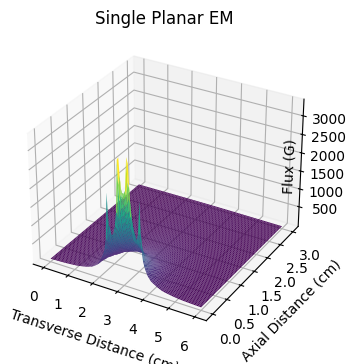

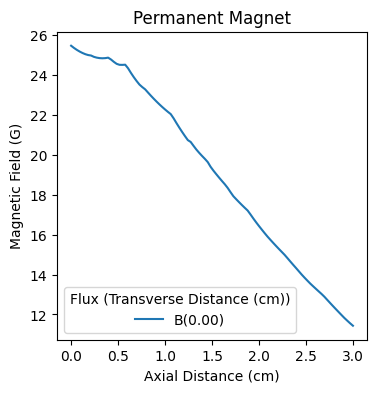

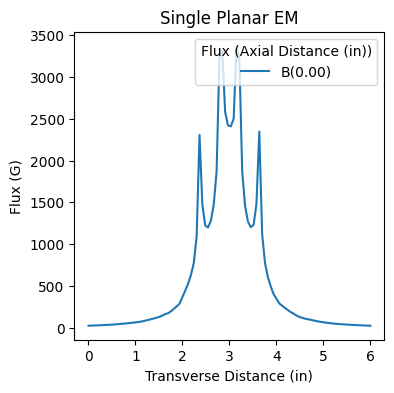

The maximum transverse gradient is 2.28e+04 G/cm at (2.79, 0.00)
The maximum axial gradient is 7.92e+00 G/cm at (0.0, 1.12)


'\nclose\n'

In [1]:
""" 
Kostubh Agarwal
kagarwal@formenergy.com
"""

import femm
import matplotlib.pyplot as plt
import numpy as np

"""
initialization
"""
femm.openfemm();
femm.newdocument(0)

"""
problem definition

magnetostatic; units of measure; axisymmetric; 
precision for the linear solver; a placeholder for 
the depth dimension; angle constraint of 30 degrees;
"""
femm.mi_probdef(0, 'inches', 'planar', 1.e-8, 7/16, 30); 
num = 100 #number of datapoints pulled from simulation
intervals = [0] #plot a singular axial and radial distance

"""
dims
"""
ax_d = 2.54
g = 3/8
w = 0.4375
h = 7/16
t = 1.25

"""
setup - materials
"""
femm.mi_getmaterial('Cast Alnico 5 (LNG40)')

femm.mi_addmaterial('Pure nickel annealed')
bdata = [0.000000, 0.056855, 0.070679, 0.088178, 0.090246, 0.092263, 0.224499, 0.257443, 0.266530, 0.288314, 0.333679, 0.352664, 0.404646, 0.410247, 0.433867, 0.470015, 0.490399, 0.494892, 0.508558, 0.546380, 0.586685, 0.590509, 0.603583, 0.613213, 0.625268, 0.632070, 0.643027, 0.682933,
0.694518, 0.737378, 0.767764, 0.883664, 0.981222, 1.009461]
hdata = [0.000000, 63.557963, 69.056222, 75.810815, 76.600889, 77.399185, 141.192593, 166.668519, 175.539259, 205.092222, 301.095185, 366.736296, 850.455185, 943.526667, 1687.981481, 3180.525926, 4166.196296, 4434.014815, 5127.622222, 7767.114815, 13328.370370, 14185.407407, 17460.481481,
19984.296296, 26455.962963, 29658.814815, 36131.629630, 63324.185185, 72483.592593, 104274.074074, 128363.703704, 220358.148148, 297860.370370, 320300.000000]
for idx in range(len(bdata)):
    femm.mi_addbhpoint('Pure nickel annealed', bdata[idx], hdata[idx])  

"""
setup - physical
"""
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0);
femm.mi_addblocklabel(0, 4);
femm.mi_selectlabel(0, 4);
femm.mi_setblockprop('Air', 1, 0, '<None>', 0, 0, 0);
femm.mi_clearselected()

femm.mi_addnode(-(g/2+w), t/2)
femm.mi_addnode(g/2+w, t/2)
femm.mi_addnode(-(g/2+w), -t/2)
femm.mi_addnode(g/2+w, -t/2)
femm.mi_addnode(-(g/2), -t/2)
femm.mi_addnode(g/2, -t/2)
femm.mi_addnode(-(g/2), t/2-w)
femm.mi_addnode(g/2, t/2-w)
femm.mi_addnode(0, t/2-w)
femm.mi_addnode(0, t/2)
femm.mi_addsegment(-(g/2+w), t/2, g/2+w, t/2)
femm.mi_addsegment(-g/2, t/2-w, g/2, t/2-w)
femm.mi_addsegment(-g/2, t/2-w, -g/2, -t/2)
femm.mi_addsegment(g/2, t/2-w, g/2, -t/2)
femm.mi_addsegment(-g/2, -t/2, -g/2-w, -t/2)
femm.mi_addsegment(g/2, -t/2, g/2+w, -t/2)
femm.mi_addsegment(-g/2-w, -t/2, -g/2-w, t/2)
femm.mi_addsegment(g/2+w, -t/2, g/2+w, t/2)
femm.mi_addsegment(0, t/2, 0, t/2-w)

femm.mi_addblocklabel(0.2, t/2-w/2);
femm.mi_selectlabel(0.2, t/2-w/2);
femm.mi_setblockprop('Cast Alnico 5 (LNG40)', 0, 0, '<None>', 90, 0, 0); #defines direction of magnetization (N/S)
femm.mi_clearselected()

femm.mi_addblocklabel(-0.2, t/2-w/2);
femm.mi_selectlabel(-0.2, t/2-w/2);
femm.mi_setblockprop('Cast Alnico 5 (LNG40)', 0, 0, '<None>', -90, 0, 0); #defines direction of magnetization (N/S)
femm.mi_clearselected()

# #additional
# femm.mi_drawrectangle(-elec_r, coil_l / 2 + elec_d - sep, elec_r, coil_l / 2 + elec_d + elec_t - sep); #working electrode
# femm.mi_addblocklabel(0, coil_l / 2 + elec_d - sep + label_tol);
# femm.mi_selectlabel(0, coil_l / 2 + elec_d - sep + label_tol);
# femm.mi_setblockprop('Pure nickel annealed', 1, 0, '<None>', 0, 0, 0);
# femm.mi_clearselected()

# femm.mi_drawrectangle(-par_r/2, - par_r + par_z - sep, par_r/2, par_r + par_z - sep); #particle
# femm.mi_addblocklabel(0, par_r + par_z - sep - par_r/2);
# femm.mi_selectlabel(0, par_r + par_z - sep - par_r/2);
# femm.mi_setblockprop('Iron', 1, 0, '<None>', 0, 2, 0);
# femm.mi_clearselected()

"""
dirichlet BC 
"""
femm.mi_makeABC(7, 6, 0, 0, 0) #Defines and Improvised Asymptotic Boundary Condition)
    
"""
save file
"""
femm.mi_zoomnatural()
femm.mi_saveas('horshoe_mag_sim.fem');

"""
mesh and solve
"""
femm.mi_analyze()
femm.mi_loadsolution()

"""
force
"""
# femm.mo_groupselectblock(2)
# par_force=femm.mo_blockintegral(19)

"""
data extraction
"""
x = np.linspace(0, 6, num) #initiliazing domain
y = np.linspace(0, 3, num) #initializing range
Z = np.zeros((num, num)) #initilizing flux array

for a in range(0, num):
    for b in range(0, num):
        s, t = femm.mo_getb(-3+x[a], -y[b] - 0.63)
        Z[a, b] = (np.sqrt(s ** 2 + t ** 2)) / 1e-4 #tesla --> gauss        

ax = plt.figure(figsize=(4,4)).add_subplot(111, projection='3d') #3d plot
Y, X = np.meshgrid(y, x)
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis', edgecolor='none')
ax.set_title('Single Planar EM')
ax.set_xlabel("Transverse Distance (cm)")
ax.set_ylabel("Axial Distance (cm)")
ax.set_zlabel("Flux (G)")
ax.zaxis.labelpad = -26

plt.figure(figsize=(4,4))  # axial flux variation
# plt.figure()  # axial flux variation
for ix in intervals:
    x_data = y  
    y_data = Z[ix, :]
    label = f'B({x[ix]:.2f})'
    plt.plot(x_data, y_data, label=label)
plt.xlabel('Axial Distance (cm)')
plt.ylabel('Magnetic Field (G)')
plt.title('Permanent Magnet')
legend = plt.legend()
legend.set_title('Flux (Transverse Distance (cm))')
plt.show()

plt.figure(figsize=(4,4))  # radial flux variation
for iy in intervals:
    x_data = x
    y_data = Z[:, iy]
    label = f'B({y[iy]:.2f})'
    plt.plot(x_data, y_data, label=label)
plt.xlabel('Transverse Distance (in)')
plt.ylabel('Flux (G)')
plt.title('Single Planar EM')
legend = plt.legend()
legend.set_title('Flux (Axial Distance (in))')
plt.show()

"""
max gradient calcs
"""
loc_r = 0 
loc_z = 0

fr = Z[:, loc_z]
fz = Z[loc_r, :]

dr = np.abs(np.diff(fr))
m_dr = np.max(dr) * (num / 6)
m_dr_i = np.argmax(dr) + 1

dz = np.abs(np.diff(fz))  
m_dz = np.max(dz) * (num / 3)
m_dz_i = np.argmax(dz) + 1

"""
output
"""
# print(f"Electrode Width/2: {elec_r:.2f} cm")
# print(f"Electrode Area: {elec_a:.2f} cm^2")
# print(f"Force on particle (rectangle with width/2 & height: {par_r:.2e}) at {par_d:.2f} cm away: {par_force:.2e} N")
print(f"The maximum transverse gradient is {m_dr:.2e} G/cm at ({x[m_dr_i]:.2f}, {y[loc_r]:.2f})")
print(f"The maximum axial gradient is {m_dz:.2e} G/cm at ({x[loc_z]}, {y[m_dz_i]:.2f})")

"""
close
"""
# femm.closefemm()
